In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from IPython.display import clear_output
%matplotlib inline

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
data_folder = "G:\Meu Drive\mestrado_final_files\data\\"


In [5]:
%run 05_functions_descriptive_analysis.ipynb

In [6]:
# with open(data_folder + 'playbyplay_data_python.pkl', 'rb') as f:
#     pbp = pickle.load(f)

pbp_tokenized = pd.read_csv(data_folder + "pbp_tokenized.txt", sep = ";")

In [227]:
pbp_tokenized\
.assign(num_tokens = lambda df: df["token"].str.count("_"))["num_tokens"].sum()

np.int64(3321118)

In [307]:
pbp_tokenized

,game_id,period,clock,token,last_time,time,spent_time,limhfouls,limvfouls,hpts,vpts,dif
0,21800001,1,12:00:00,p000_12(1)p455_10(0),7200,7200,0,4,4,0,0,0
1,21800001,1,11:40:00,p500_2(5)p200_4(0t),7200,7000,200,4,4,0,0,0
2,21800001,1,11:15:00,p400_2(5),7000,6750,250,4,4,0,0,0
3,21800001,1,11:13:00,p500_4(0p),6750,6730,20,4,4,0,0,0
4,21800001,1,11:08:00,p540_5(11p),6730,6680,50,4,4,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2565572,52200211,4,00:50:80,p540_5(35p),650,508,142,1,0,120,93,27
2565573,52200211,4,00:47:50,p401_5(12p),508,475,33,1,0,120,93,27
2565574,52200211,4,00:37:70,p550_1(3a),475,377,98,1,0,120,95,25
2565575,52200211,4,00:13:60,p201_5(37t),377,136,241,1,0,120,95,25


In [ ]:
df_games_nba = pd.read_csv(data_folder + "games_nba.csv", sep = ';')

In [48]:
df_arremessos = pd.read_csv(data_folder + "agregacoes_arremessos.csv", sep = ";")

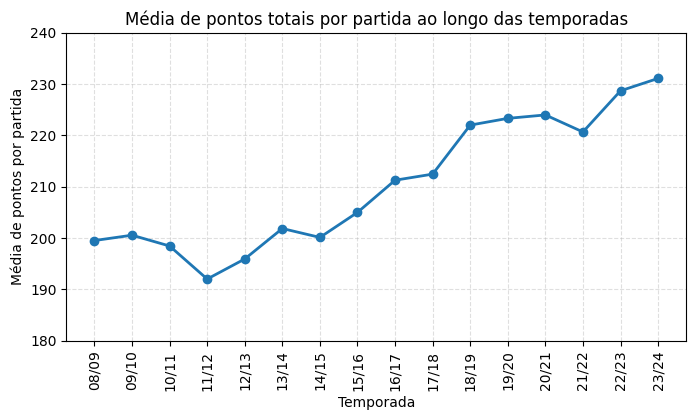

In [124]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

df_pontos = df_arremessos\
.assign(SEASON = lambda df: df["SEASON"].str.slice(-5,).str.replace("-", "/"))\
.query("acao_agrupada in ['arremesso convertido 2 pts', 'arremesso convertido 3 pts', 'lance livre correto']")\
.pivot_table(index = "SEASON", columns = "acao_agrupada", values = "media")\
.assign(pontos = lambda df: (3 * df["arremesso convertido 3 pts"]) + (2 * df["arremesso convertido 2 pts"]) + df["lance livre correto"])\
.assign(pontos = lambda df: df["pontos"] / 1000)

df_pontos\
[["pontos"]].plot(ylim = [180, 240], marker="o", linewidth = 2, ax = ax)

ax.set_title("Média de pontos totais por partida ao longo das temporadas", fontsize=12)
ax.set_xlabel("Temporada")
ax.set_ylabel("Média de pontos por partida")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.legend_.remove()

# Mostrar todas as temporadas e rotacionar em 90 graus
ax.set_xticks(range(len(df_pontos.index)))
ax.set_xticklabels(df_pontos.index, rotation=90)


plt.show()

In [103]:
df_arremessos\
.assign(SEASON = lambda df: df["SEASON"].str.slice(-5,).str.replace("-", "/"))\
.pivot_table(index= "acao_agrupada", columns="SEASON", values="media").T\
.assign(apr = lambda df: df["lance livre correto"] / (df["lance livre correto"] + df["lance livre errado"]))

acao_agrupada,arremesso convertido 2 pts,arremesso convertido 3 pts,arremesso errado 2 pts,arremesso errado 3 pts,lance livre correto,lance livre errado,apr
SEASON,,,,,,,
08/09,60625.095057,13323.193916,64346.768061,23071.482890,38272.243346,11414.448669,0.770272
09/10,62192.835366,12889.481707,64336.890244,23497.713415,37478.658537,11929.878049,0.758546
10/11,61213.577422,12871.853547,64733.028223,23142.639207,37381.388253,11530.892449,0.764254
11/12,59899.441341,12743.947858,65879.888268,23920.856611,33959.962756,11148.975791,0.752843
12/13,59685.692542,14313.546423,64009.893455,25693.302892,33587.519026,11022.831050,0.752909
13/14,59720.242608,15526.914329,62689.916603,27651.250948,35811.978772,11511.751327,0.756745
14/15,59135.774218,15807.780320,62900.076278,29406.559878,34405.797101,11549.961861,0.748672
15/16,59139.057751,17115.501520,61431.610942,31268.237082,35352.583587,11395.136778,0.756242
16/17,58624.140565,19410.236822,57735.676089,34844.155844,35763.177998,10546.982429,0.772253


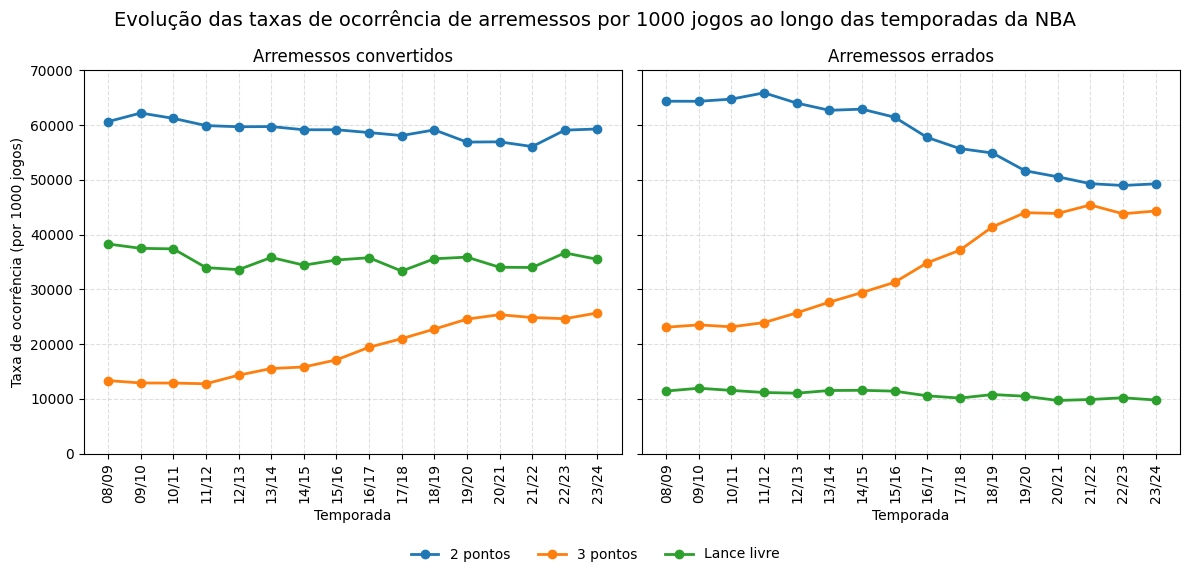

In [94]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# Painel 1: arremessos convertidos
df_made = (
    df_arremessos
    .query("acao_agrupada in ['arremesso convertido 2 pts', 'arremesso convertido 3 pts', 'lance livre correto']")
    .assign(SEASON = lambda df: df["SEASON"].str.slice(-5,).str.replace("-", "/"))
    .pivot_table(index="SEASON", columns="acao_agrupada", values="media")
    .sort_index()
)

df_made.plot(
    ax=ax[0],
    marker="o",
    linewidth=2
)

ax[0].set_title("Arremessos convertidos", fontsize=12)
ax[0].set_xlabel("Temporada")
ax[0].set_ylabel("Taxa de ocorrência (por 1000 jogos)")
ax[0].grid(axis="y", linestyle="--", alpha=0.4)
ax[0].grid(axis="x", linestyle="--", alpha=0.4)
ax[0].set_ylim(0, 70000)
ax[0].legend_.remove()

# Painel 2: arremessos errados
df_missed = (
    df_arremessos
    .query("acao_agrupada in ['arremesso errado 2 pts', 'arremesso errado 3 pts', 'lance livre errado']")
    .assign(SEASON = lambda df: df["SEASON"].str.slice(-5,).str.replace("-", "/"))
    .pivot_table(index="SEASON", columns="acao_agrupada", values="media")
    .sort_index()
)

df_missed.plot(
    ax=ax[1],
    marker="o",
    linewidth=2
)

ax[1].set_title("Arremessos errados", fontsize=12)
ax[1].set_xlabel("Temporada")
ax[1].set_ylabel("")
ax[1].grid(axis="y", linestyle="--", alpha=0.4)
ax[1].grid(axis="x", linestyle="--", alpha=0.4)
ax[1].set_ylim(0, 70000)
ax[1].legend_.remove()

# Mostrar todas as temporadas e rotacionar em 90 graus
for a in ax:
    a.set_xticks(range(len(df_made.index)))
    a.set_xticklabels(df_made.index, rotation=90)

# Legenda única
handles, labels = ax[0].get_legend_handles_labels()
handles2, labels2 = ax[1].get_legend_handles_labels()

fig.legend(handles, ["2 pontos", "3 pontos", "Lance livre"],
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01)
)

fig.suptitle(
    "Evolução das taxas de ocorrência de arremessos por 1000 jogos ao longo das temporadas da NBA",
    fontsize=14, y = 0.93
)

fig.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [137]:
df_regras = pd.read_csv(data_folder + "agregacoes_sub_timeout_instant_replay.csv", sep = ";")\
.assign(SEASON = lambda df: df["SEASON"].str.slice(-5,).str.replace("-", "/"))

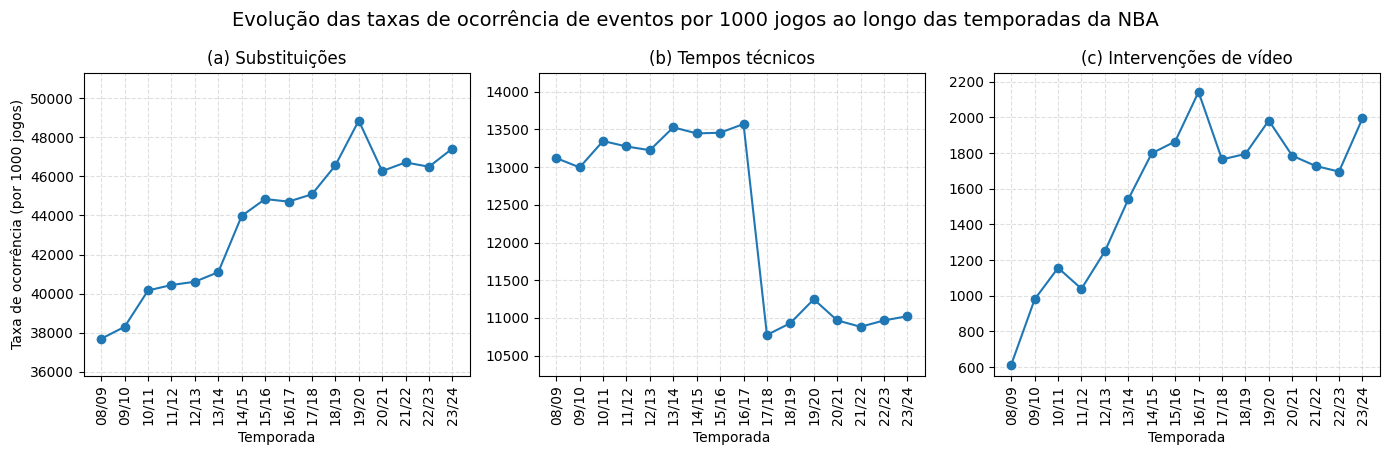

In [142]:
fig, ax = plt.subplots(1, 3, figsize=(14, 5), sharex=True)

# Substituições
df_sub = df_regras.query("acao == 8")
ax[0].plot(df_sub["SEASON"], df_sub["media"], marker='o')
ax[0].set_title("(a) Substituições")
ax[0].set_ylabel("Taxa de ocorrência (por 1000 jogos)")
ax[0].grid(True, linestyle='--', alpha=0.4)

ymin = df_sub["media"].min() * 0.95
ymax = df_sub["media"].max() * 1.05
ax[0].set_ylim(ymin, ymax)

# Tempo técnico
df_tt = df_regras.query("acao == 9")
ax[1].plot(df_tt["SEASON"], df_tt["media"], marker='o')
ax[1].set_title("(b) Tempos técnicos")
ax[1].grid(True, linestyle='--', alpha=0.4)

ymin = df_tt["media"].min() * 0.95
ymax = df_tt["media"].max() * 1.05
ax[1].set_ylim(ymin, ymax)


# Intervenções de vídeo
df_video = df_regras.query("acao == 18")
ax[2].plot(df_video["SEASON"], df_video["media"], marker='o')
ax[2].set_title("(c) Intervenções de vídeo")
ax[2].grid(True, linestyle='--', alpha=0.4)

ymin = df_video["media"].min() * 0.9
ymax = df_video["media"].max() * 1.05
ax[2].set_ylim(ymin, ymax)

# Ajuste eixo X
for a in ax:
    a.set_xlabel("Temporada")
    a.tick_params(axis='x', rotation=90)

fig.suptitle(
    "Evolução das taxas de ocorrência de eventos por 1000 jogos ao longo das temporadas da NBA",
    fontsize=14,
    y=0.93
)

fig.tight_layout(rect=[0, 0.03, 1, 0.95])

In [145]:
FOLDER_PROCESSED_DATA = "C:/Users/User/Documents/recuperacao_arquivoshd/Mestrado/NBA/nba/data/processed/pbp_season_files/concatenate_data/"

In [149]:
df_pbp_total = pd.read_parquet(FOLDER_PROCESSED_DATA + "pbp_total.parquet")\
.query("tp_event.notna()").astype({"tp_event": "int"})

In [306]:
#print(df_pbp_total.query("game_id == '0022301230'")[["period", "clock", "description"]].reset_index(drop = True))

print(df_pbp_total.query("game_id == '0022301230'")[["xlegacy", "ylegacy"]].reset_index(drop=True))

     xlegacy  ylegacy
0       <NA>     <NA>
1       <NA>     <NA>
2      -18.0     10.0
3       <NA>     <NA>
4       <NA>     <NA>
..       ...      ...
458     <NA>     <NA>
459     <NA>     <NA>
460    154.0    236.0
461     <NA>     <NA>
462     <NA>     <NA>

[463 rows x 2 columns]


In [284]:
pbp_tokenized\
.merge(df_games_nba.rename(columns = {"GAME_ID": "game_id"})[["game_id", "SEASON"]], how = "left")\
.assign(num_games = lambda df: df.groupby("SEASON")["game_id"].transform("nunique"))\
.query("token.str.contains('_1\(|_2\(')")\
.assign(token_ = lambda df: df["token"].str.replace("p[0-9]{3}_(3|4|5|6|7|8|9|10|11|12|13|18)\(.+?\)", "", regex = True))\
.assign(token_ = lambda df: df["token_"].str.replace("p[0-9]{3}_", "", regex = True))\
.groupby(["SEASON", "num_games", "token_"], as_index = False, dropna = False).size()\
.assign(media = lambda df: 1000 * df["size"] / df["num_games"])\
.pivot_table(index = "token_", columns = "SEASON", values = "media")\
.assign(coef_var = lambda df: df.apply(lambda x: np.std(x) / np.mean(x), axis = 1))\
.assign(coef_var = lambda df: df["coef_var"].round(4).astype("str"))\
.round(2)\
.reset_index()\
.assign(tipo_evento = lambda df: np.where(df["token_"].str[0] == "1", "Made Shot", "Missed Shot"))\
.assign(tipo_subevento_simp = lambda df: np.where(df["token_"].str.contains("\(1"), "Dunk Shot (2pt)", ""))\
.assign(tipo_subevento_simp = lambda df: np.where(df["token_"].str.contains("\(2"), "Hook Shot (2pt)", df["tipo_subevento_simp"]))\
.assign(tipo_subevento_simp = lambda df: np.where(df["token_"].str.contains("\(3"), "Layup Shot (2pt)", df["tipo_subevento_simp"]))\
.assign(tipo_subevento_simp = lambda df: np.where(df["token_"].str.contains("\(4"), "Others Shot (2pt)", df["tipo_subevento_simp"]))\
.assign(tipo_subevento_simp = lambda df: np.where(df["token_"].str.contains("\(5"), "Any Shot (3pt)", df["tipo_subevento_simp"]))\
.assign(adicional = lambda df: np.where(df["token_"].str.contains("a"), "com assistência", ""))\
.assign(adicional = lambda df: np.where(df["token_"].str.contains("b"), "bloqueado", df["adicional"]))\
[['tipo_evento', 'tipo_subevento_simp', 'adicional', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', 'coef_var']]\
.reset_index(drop = True)

SEASON,tipo_evento,tipo_subevento_simp,adicional,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,coef_var
0,Made Shot,Dunk Shot (2pt),,2164.63,2174.98,1977.78,2024.19,2236.36,2245.78,0.0476
1,Made Shot,Dunk Shot (2pt),com assistência,7009.91,7027.12,6414.53,6919.12,7133.33,7268.67,0.0385
2,Made Shot,Hook Shot (2pt),,1576.22,1132.98,1205.98,1120.94,1199.24,1087.95,0.1348
3,Made Shot,Hook Shot (2pt),com assistência,1657.01,1305.34,1270.94,1301.59,1423.48,1454.22,0.0943
4,Made Shot,Layup Shot (2pt),,13826.22,13937.01,13664.96,13185.94,13853.03,13522.89,0.0185
5,Made Shot,Layup Shot (2pt),com assistência,13102.90,12489.06,12686.32,12653.82,13351.52,14496.39,0.0516
6,Made Shot,Others Shot (2pt),,11218.75,11077.87,11700.85,11052.15,11756.06,10643.37,0.0344
7,Made Shot,Others Shot (2pt),com assistência,8557.93,7740.16,8010.26,7808.01,8110.61,8562.65,0.0402
8,Made Shot,Any Shot (3pt),,4077.74,4559.93,4537.61,4478.46,4225.76,4034.94,0.0499
9,Made Shot,Any Shot (3pt),com assistência,18648.63,19990.38,20821.37,20365.08,20403.79,21644.58,0.0446


In [245]:
df_pbp_total\
.assign(num_games = lambda df: df.groupby("season")["game_id"].transform("nunique"))\
.query("season >= '2018-19' & tp_event == 1 & description.str.contains('Layup')")\
.groupby(["season", "num_games", "tp_subaction"], as_index = False).size()\
.assign(media = lambda df: 1000 * df["size"] / df["num_games"])\
.pivot_table(index = "tp_subaction", columns = "season", values = "media")\
.assign(coef_var = lambda df: df.apply(lambda x: np.std(x) / np.mean(x), axis = 1))\
.assign(coef_var = lambda df: df["coef_var"].round(4).astype("str"))\
.round(2)\
.reset_index()

season,tp_subaction,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,coef_var
0,Alley Oop Layup shot,544.97,495.19,505.55,474.68,428.79,411.35,0.0954
1,Cutting Finger Roll Layup Shot,431.40,479.44,413.32,446.71,453.03,413.71,0.0529
2,Cutting Layup Shot,3035.82,3076.12,3014.52,2931.97,3121.97,2917.26,0.0242
3,Driving Finger Roll Layup Shot,2262.96,2618.55,2397.10,2599.40,2835.61,3050.83,0.0994
4,Driving Layup Shot,7756.86,7598.43,7675.49,7173.09,7603.79,7771.87,0.0264
5,Driving Reverse Layup Shot,1038.11,1110.24,1046.97,919.12,1007.58,1075.65,0.0581
6,Finger Roll Layup Shot,291.16,242.34,210.08,223.73,219.70,196.22,0.1322
7,Layup,NaN,NaN,NaN,NaN,NaN,513.00,0.0
8,Layup Shot,4141.01,3216.10,3211.78,3077.85,2332.58,2330.97,0.2018
9,Putback Layup Shot,1500.76,1615.05,1759.18,1808.77,1884.85,1983.45,0.0917


In [184]:
xdf2 = df_pbp_total\
.query("tp_event not in [1, 3, 8, 11, 12, 13]")\
.query("~(tp_event == 18 & person_types in ['001', '000'])")\
.query("~(tp_event == 2 & person_types in ['400', '405', '500', '504'])")\
.query("~(tp_event == 4 & person_types in ['200', '300', '400', '500'])")\
.query("~(tp_event == 5 & person_types in ['200', '201', '300', '301', '400', '401', '450', '500', '501', '540', '541', '451'])")\
.query("~(tp_event == 6 & person_types in ['201', '301', '401', '501', '451', '541', '601', '701', '471', '741', '651', '671'])")\
.query("~(tp_event == 7 & person_types in ['200', '201', '300', '301', '400', '401', '500', '501', '450', '451', '540', '541'])")\
.query("~(tp_event == 10 & person_types in ['452', '453', '454', '455'])")\
.query("~(tp_event == 9 & person_types in ['100', '200', '300'])")

In [231]:
df_pbp_total.query("tp_event == 9 & season >= '2018-19'")["tp_subaction"].value_counts()

tp_subaction
Regular            77153
Coach Challenge      918
full                 162
challenge              3
Name: count, dtype: Int64

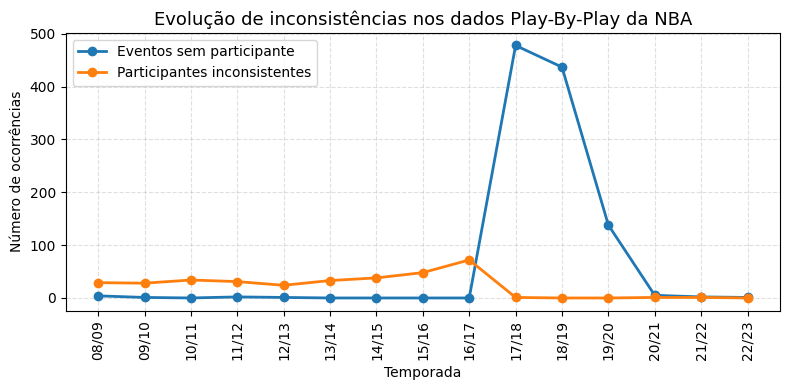

In [201]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

df_ = xdf2\
.assign(season = lambda df: df["season"].str.slice(-5,).str.replace("-", "/"))\
.assign(ind_identificacao = lambda df: np.where(df["person_types"].isin(["000", "001"]), "Eventos sem participante", "Participantes inconsistentes"))\
.groupby(['season', 'ind_identificacao'], as_index = False, dropna = False).size()\
.pivot_table(index = "season", columns = "ind_identificacao", values = "size")\
.fillna(0)

df_.plot(marker="o", linewidth = 2, ax = ax)

ax.set_title("Evolução de inconsistências nos dados Play-By-Play da NBA", fontsize=13)
ax.set_xlabel("Temporada")
ax.set_ylabel("Número de ocorrências")

#ax.set_ylabel("Média de pontos por partida")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.legend_.remove()

# Mostrar todas as temporadas e rotacionar em 90 graus
ax.set_xticks(range(len(df_.index)))
ax.set_xticklabels(df_.index, rotation=90)

# ax.axvline(x="17/18", linestyle="--", alpha=0.7)
# ax.text(9.5, 450, "Mudança de provedor", rotation=90, va="center")

# ax.tick_params(axis='x', rotation=90)

ax.legend()

plt.tight_layout()

plt.show()

In [187]:
xdf2\
.groupby(["tp_event", "person_types"], as_index = False, dropna = False).size()\
.pivot_table(index = "person_types", columns = "tp_event", values = "size")\
.fillna("")

tp_event,2,4,5,6,7,9,10,18
person_types,,,,,,,,
000,,30.0,,,107.0,20.0,,
001,,,5.0,30.0,877.0,,,
051,,,,,,,,2.0
251,,,,1.0,,,,
400,,,,,,21.0,,
405,,,26.0,,,,,
450,,,,1.0,,,10.0,
454,,,1.0,,,,,
455,,,123.0,,,,,


In [6]:
columns_boxscore = ["home_FGM", "away_FGM", "home_FGA", "away_FGA", "home_FGP", "away_FGP", 
                    "home_3FGM", "away_3FGM", "home_3FGA", "away_3FGA", "home_3FGP", "away_3FGP", 
                    "home_FTM", "away_FTM", "home_FTA", "away_FTA", "home_FTP", "away_FTP", 
                    "home_RebOff", "away_RebOff", "home_RebDef", "away_RebDef", "home_RebTot", 
                    "away_RebTot", "home_AST", "away_AST", "home_STL", "away_STL", "home_BLK", 
                    "away_BLK", "home_TO", "away_TO", "home_FP", "away_FP", "home_points", 
                    "away_points", "home_PMP", "away_PMP", 'home_outcome', 'away_outcome']

df_boxscore = pd.read_csv(data_folder + 'boxscore_moving_average20.txt', sep = ';')\
.set_index("game_id")\
[columns_boxscore]

In [7]:
df_pts = pbp["train"]\
.drop(columns = ["period_", "period1"])\
.iloc[:, :17].query("period <= 4")\
.assign(time_list = lambda df: df["clock"].str.split(":"))\
.assign(time_list = lambda df: df["time_list"].apply(lambda x: [int(i) for i in x]))\
.assign(remaining_time = lambda df: df["time_list"].apply(lambda x: (x[0] * 600) + (x[1] * 10) + int(x[2] / 10)))\
[["game_id", "period", "hpts", "vpts", "remaining_time"]]\
.merge(df_games_nba[["GAME_ID", 'SEASON']], how = "left", left_on = "game_id", right_on = 'GAME_ID')

In [8]:
df_pts.groupby("game_id")[["hpts", "vpts"]].max().describe()

,hpts,vpts
count,5676.000000,5676.000000
mean,112.705603,110.725863
std,12.319356,12.090565
min,73.000000,68.000000
25%,104.000000,103.000000
50%,112.000000,111.000000
75%,121.000000,119.000000
max,158.000000,159.000000


In [13]:
df_pts\
.groupby("game_id")[["hpts", "vpts"]].max()\
.assign(dif = lambda df: df["hpts"] - df["vpts"])\
.assign(signal = lambda df: np.sign(df["dif"]))\
["signal"].value_counts(normalize = True)

signal
 1    0.530479
-1    0.415257
 0    0.054264
Name: proportion, dtype: float64

In [13]:
list_points = []
list_labels = ["a. ( < -20)", "b. (entre -20 e -10)", "c. (entre -10 e -5)", "d. (entre -5 e -3)", "e. (entre -3 e 3)", "f. (entre 3 e 5)", "g. (entre 5 e 10)", "h. (entre 10 e 20)", "i. ( > 20)"]
for p in [1, 2, 3, 4]:
    for t in [7200, 6600, 6000, 5400, 4800, 4200, 3600, 3000, 2400, 1800, 1200, 600, 200, 100, 0]:
        print(f"Calculating the points for period: {p} and remaining time: {t}")
        df_ = df_pts\
        .query("period == @p & remaining_time >= @t")\
        .groupby(["game_id"])\
        .apply(lambda df: df.iloc[[-1]], include_groups = False)\
        .assign(dif_pts = lambda df: df["hpts"] - df['vpts'])\
        .assign(cat_dif = lambda df: pd.cut(df["dif_pts"], bins = [-100, -20, -10, -5, -3, 3, 5, 10, 20, 100], labels = list_labels))\
        .assign(cat_dif = lambda df: df["cat_dif"].astype('str'))\
        .groupby(["cat_dif"], observed = False)\
        .apply(lambda df: df[["hpts", "vpts"]].describe().T, include_groups = False)\
        .reset_index()\
        .assign(period = p, ref_remaining_time = t)
        
        list_points.append(df_)
        clear_output(wait = True)

Calculating the points for period: 4 and remaining time: 0


In [14]:
df_pts\
.assign(dif_pts = lambda df: df["hpts"] - df['vpts'])\
.assign(cat_dif = lambda df: pd.cut(df["dif_pts"], bins = [-100, -20, -10, -5, -3, 3, 5, 10, 20, 100], labels = list_labels))\
.assign(cat_dif = lambda df: df["cat_dif"].astype('str'))\
.groupby("cat_dif", as_index = False).size()\
.assign(perc = lambda df: 100 * df["size"] / df["size"].sum())\
.assign(percacm = lambda df: 100 * df["size"].cumsum() / df["size"].sum())

,cat_dif,size,perc,percacm
0,a. ( < -20),73651,3.615971,3.615971
1,b. (entre -20 e -10),232960,11.437409,15.053380
2,c. (entre -10 e -5),265778,13.048642,28.102022
3,d. (entre -5 e -3),146854,7.209947,35.311968
4,e. (entre -3 e 3),525475,25.798731,61.110699
5,f. (entre 3 e 5),146362,7.185792,68.296491
6,g. (entre 5 e 10),274600,13.481767,81.778258
7,h. (entre 10 e 20),269979,13.254894,95.033152
8,i. ( > 20),101166,4.966848,100.000000


In [25]:
df_points_by_minute_by_diff = pd.concat(list_points)\
.sort_values(["cat_dif", "level_1", "period", "ref_remaining_time"], ascending = [True, True, True, False])\
.assign(lag_pts = lambda df: df.groupby(["cat_dif", "level_1"])["mean"].shift(1).fillna(0))\
.assign(lag_cnt = lambda df: df.groupby(["cat_dif", "level_1"])["count"].shift(1).fillna(0))\
.assign(pts = lambda df: df["mean"] - df["lag_pts"])\
.assign(index = lambda df: ["away_pts" if i == "vpts" else "home_pts" for i in df["level_1"]])\
.query("count >= 100 & lag_cnt >= 100")\
.pivot_table(index = ["ref_remaining_time", "cat_dif"], columns = ["index", "period"], values = "pts")\
.reset_index()\
.sort_values(["cat_dif", "ref_remaining_time"], ascending = [True, False])\
.reset_index(drop = True)

df_points_by_minute_by_diff.columns = ["ref_remaining_time", "cat_dif", "away_pts1", "away_pts2", "away_pts3", "away_pts4", "home_pts1", "home_pts2", "home_pts3", "home_pts4"]

In [30]:
df_points_by_minute_by_diff.query("cat_dif.str.contains('^a.')").fillna('-')

,ref_remaining_time,cat_dif,away_pts1,away_pts2,away_pts3,away_pts4,home_pts1,home_pts2,home_pts3,home_pts4
0,7200,a. ( < -20),-,-,-0.022885,0.000000,-,-,0.001438,0.002833
1,6600,a. ( < -20),-,-,2.097162,1.564062,-,-,1.877636,1.400960
2,6000,a. ( < -20),-,-,1.821269,2.911874,-,-,1.878223,2.373687
3,5400,a. ( < -20),-,-,2.357636,2.197348,-,-,2.127241,2.297201
4,4800,a. ( < -20),-,-,2.532134,1.672484,-,-,2.613287,1.670984
5,4200,a. ( < -20),-,-,2.696653,2.897698,-,-,2.251762,2.718670
6,3600,a. ( < -20),-,1.979375,2.175962,2.153341,-,1.927419,2.481036,2.101947
7,3000,a. ( < -20),-,2.871457,2.026316,2.132694,-,2.754399,2.011879,2.389577
8,2400,a. ( < -20),-,2.664918,2.787797,2.245395,-,2.339161,2.426316,2.043976
9,1800,a. ( < -20),-,2.537288,2.496006,2.147575,-,2.153518,2.355556,2.009969


In [31]:
df_points_by_minute_by_diff.query("cat_dif.str.contains('^b.')").fillna('-')

,ref_remaining_time,cat_dif,away_pts1,away_pts2,away_pts3,away_pts4,home_pts1,home_pts2,home_pts3,home_pts4
15,7200,b. (entre -20 e -10),-,-0.006968,-0.000604,-0.003021,-,-0.003729,0.006303,-0.003762
16,6600,b. (entre -20 e -10),-,1.826064,1.849065,1.926425,-,1.825267,1.742039,1.797348
17,6000,b. (entre -20 e -10),-,2.218168,2.392989,2.026379,-,2.068222,2.329565,2.036914
18,5400,b. (entre -20 e -10),-,2.269529,2.565686,2.165172,-,2.231298,2.443996,2.159862
19,4800,b. (entre -20 e -10),-,2.258317,2.055337,2.296261,-,2.160524,2.240315,2.137937
20,4200,b. (entre -20 e -10),2.366415,2.525972,2.590963,1.941508,1.992053,2.577008,2.402675,1.905883
21,3600,b. (entre -20 e -10),3.107739,2.636419,2.087392,2.497150,2.575679,2.459419,2.198292,2.514611
22,3000,b. (entre -20 e -10),2.180476,2.167532,2.423642,2.000440,2.094305,2.184527,2.442547,2.095059
23,2400,b. (entre -20 e -10),2.462772,2.333729,2.469471,2.466106,2.226356,2.299182,2.261193,2.414731
24,1800,b. (entre -20 e -10),2.49727,2.383312,2.211318,2.345934,2.381978,2.268579,2.190038,2.400271


In [32]:
df_points_by_minute_by_diff.query("cat_dif.str.contains('^c.')").fillna('-')

,ref_remaining_time,cat_dif,away_pts1,away_pts2,away_pts3,away_pts4,home_pts1,home_pts2,home_pts3,home_pts4
30,7200,c. (entre -10 e -5),-,0.006981,-0.027272,0.026481,-,0.006054,-0.028730,0.027668
31,6600,c. (entre -10 e -5),-,1.696795,1.871210,1.907811,-,1.778735,1.868453,1.917475
32,6000,c. (entre -10 e -5),2.241917,2.535124,2.203293,2.337433,1.466587,2.478210,2.264426,2.339743
33,5400,c. (entre -10 e -5),2.305869,2.353230,2.527708,2.057186,1.983784,2.372802,2.574939,2.081782
34,4800,c. (entre -10 e -5),2.496031,2.441960,2.774073,2.781079,2.332112,2.506574,2.640834,2.751783
35,4200,c. (entre -10 e -5),2.39348,2.127049,1.849879,1.907133,2.317194,1.999952,1.864890,1.887505
36,3600,c. (entre -10 e -5),2.309166,2.164641,2.348638,2.080106,2.159406,2.181735,2.483179,2.176685
37,3000,c. (entre -10 e -5),2.515545,2.391143,2.289670,2.450642,2.430902,2.381153,2.187755,2.327527
38,2400,c. (entre -10 e -5),2.372212,2.279064,2.457694,2.129363,2.471167,2.322578,2.476874,2.095540
39,1800,c. (entre -10 e -5),2.322279,2.520852,2.527254,1.927503,2.252129,2.510272,2.481166,1.963241


In [33]:
df_points_by_minute_by_diff.query("cat_dif.str.contains('^d.')").fillna('-')

,ref_remaining_time,cat_dif,away_pts1,away_pts2,away_pts3,away_pts4,home_pts1,home_pts2,home_pts3,home_pts4
45,7200,d. (entre -5 e -3),-,0.005699,0.112489,-0.022175,-,0.004698,0.111320,-0.017617
46,6600,d. (entre -5 e -3),-,2.221505,1.384570,1.459977,-,2.210753,1.359017,1.479403
47,6000,d. (entre -5 e -3),2.112449,1.966979,2.671910,1.757436,1.980159,1.967220,2.668957,1.720000
48,5400,d. (entre -5 e -3),2.330993,2.287636,1.905391,3.190476,2.287327,2.297282,1.921245,3.187857
49,4800,d. (entre -5 e -3),2.381938,2.688655,2.136213,1.601963,2.388993,2.655038,2.122248,1.525753
50,4200,d. (entre -5 e -3),2.335209,2.201478,2.730739,3.421027,2.315999,2.244499,2.723232,3.463343
51,3600,d. (entre -5 e -3),2.500535,2.251440,2.184319,0.994710,2.541714,2.220464,2.228961,0.999021
52,3000,d. (entre -5 e -3),2.265585,2.444813,1.916590,2.166636,2.272497,2.428654,1.862270,2.177466
53,2400,d. (entre -5 e -3),2.558616,2.186463,2.106344,2.239771,2.525999,2.203295,2.154483,2.275934
54,1800,d. (entre -5 e -3),2.424174,1.957810,3.050072,2.176026,2.447327,1.979921,3.000570,2.189696


In [34]:
df_points_by_minute_by_diff.query("cat_dif.str.contains('^e.')").fillna('-')

,ref_remaining_time,cat_dif,away_pts1,away_pts2,away_pts3,away_pts4,home_pts1,home_pts2,home_pts3,home_pts4
60,7200,e. (entre -3 e 3),-,0.000110,0.003387,0.002638,-,-0.002155,-0.005080,-0.000796
61,6600,e. (entre -3 e 3),1.452939,1.828800,2.001417,2.002643,1.766681,1.795404,1.997161,1.973561
62,6000,e. (entre -3 e 3),2.24805,2.537601,2.326902,2.262053,2.330468,2.463523,2.286370,2.304634
63,5400,e. (entre -3 e 3),2.486811,2.222625,2.368140,2.175736,2.486469,2.222044,2.385492,2.206136
64,4800,e. (entre -3 e 3),2.384131,2.101948,2.307775,1.922448,2.458602,2.246273,2.298800,1.945471
65,4200,e. (entre -3 e 3),2.470585,2.419858,2.437492,2.076705,2.555176,2.283886,2.529373,2.012739
66,3600,e. (entre -3 e 3),2.410961,2.444111,2.619212,2.452637,2.366419,2.463407,2.647736,2.456097
67,3000,e. (entre -3 e 3),2.378176,2.344806,2.571624,2.223242,2.366325,2.294317,2.471504,2.230188
68,2400,e. (entre -3 e 3),2.344015,2.200930,2.101850,1.994150,2.37568,2.248771,2.170052,1.995385
69,1800,e. (entre -3 e 3),2.453266,2.658436,2.153782,2.258152,2.37038,2.627115,2.117783,2.251357


In [35]:
df_points_by_minute_by_diff.query("cat_dif.str.contains('^f.')").fillna('-')

,ref_remaining_time,cat_dif,away_pts1,away_pts2,away_pts3,away_pts4,home_pts1,home_pts2,home_pts3,home_pts4
75,7200,f. (entre 3 e 5),-,0.000000,0.003110,-0.000923,-,0.000000,0.003195,-0.002433
76,6600,f. (entre 3 e 5),-,1.710954,2.059160,1.661585,-,1.761491,2.056967,1.682927
77,6000,f. (entre 3 e 5),1.886925,1.958243,2.201506,1.989248,1.893639,1.909789,2.187746,1.962170
78,5400,f. (entre 3 e 5),2.211096,3.005962,2.572516,1.655618,2.2325,3.008072,2.602204,1.689745
79,4800,f. (entre 3 e 5),2.656747,2.263865,2.611016,3.207430,2.639974,2.249340,2.621413,3.132267
80,4200,f. (entre 3 e 5),2.463522,2.111634,1.975032,1.920654,2.470956,2.132821,1.949560,1.970493
81,3600,f. (entre 3 e 5),2.33706,1.685237,2.535026,1.711797,2.347458,1.671878,2.589135,1.739911
82,3000,f. (entre 3 e 5),2.223239,2.445039,2.411355,2.063704,2.239528,2.419672,2.383275,2.064044
83,2400,f. (entre 3 e 5),2.2835,2.648233,2.272767,2.607402,2.270891,2.670495,2.233976,2.559042
84,1800,f. (entre 3 e 5),2.408245,3.028249,2.163364,2.718829,2.425608,3.012938,2.181343,2.752876


In [36]:
df_points_by_minute_by_diff.query("cat_dif.str.contains('^g.')").fillna('-')

,ref_remaining_time,cat_dif,away_pts1,away_pts2,away_pts3,away_pts4,home_pts1,home_pts2,home_pts3,home_pts4
90,7200,g. (entre 5 e 10),-,0.000000,-0.007463,0.001383,-,0.003363,0.002488,0.000000
91,6600,g. (entre 5 e 10),-,1.639829,1.549041,1.568376,-,1.607929,1.519294,1.672398
92,6000,g. (entre 5 e 10),-,2.429111,2.364828,2.320874,-,2.443459,2.430637,2.289603
93,5400,g. (entre 5 e 10),2.00234,2.128213,2.568146,2.227558,2.359965,2.167339,2.519693,2.135170
94,4800,g. (entre 5 e 10),2.107843,2.358280,2.510130,2.114311,2.264912,2.386784,2.454923,2.196723
95,4200,g. (entre 5 e 10),2.432081,2.545159,2.358171,2.128378,2.632075,2.439292,2.448118,2.226515
96,3600,g. (entre 5 e 10),2.164448,2.198190,2.124434,2.472982,2.22745,2.278290,2.016956,2.324917
97,3000,g. (entre 5 e 10),2.540859,2.003531,2.338841,2.147382,2.484001,2.103143,2.334635,2.137151
98,2400,g. (entre 5 e 10),2.328538,2.643279,2.512464,1.979392,2.413527,2.575097,2.546602,1.958964
99,1800,g. (entre 5 e 10),2.336534,1.995352,2.123779,1.794336,2.270871,2.032225,2.190171,1.881331


In [37]:
df_points_by_minute_by_diff.query("cat_dif.str.contains('^h.')").fillna('-')

,ref_remaining_time,cat_dif,away_pts1,away_pts2,away_pts3,away_pts4,home_pts1,home_pts2,home_pts3,home_pts4
105,7200,h. (entre 10 e 20),-,0.000000,0.004629,0.002114,-,0.000000,0.012948,0.003171
106,6600,h. (entre 10 e 20),-,2.061404,1.956425,2.003807,-,1.998095,2.142827,1.994728
107,6000,h. (entre 10 e 20),-,1.941638,2.288440,2.207539,-,2.091303,2.205466,2.293830
108,5400,h. (entre 10 e 20),-,2.278367,2.389171,2.251641,-,2.389484,2.394868,2.203686
109,4800,h. (entre 10 e 20),-,2.248403,2.149740,2.271232,-,2.239504,2.117658,2.370726
110,4200,h. (entre 10 e 20),1.793053,2.114480,2.366911,2.038387,2.116632,2.187664,2.667446,2.098860
111,3600,h. (entre 10 e 20),2.078947,2.405109,2.439866,2.082250,2.440226,2.520551,2.393730,2.068594
112,3000,h. (entre 10 e 20),1.956447,2.433150,2.349000,2.263772,2.332931,2.593527,2.224968,2.228373
113,2400,h. (entre 10 e 20),2.201,2.377600,2.510189,2.458482,2.541588,2.222652,2.470407,2.415090
114,1800,h. (entre 10 e 20),2.387863,2.533648,2.577867,2.227307,2.330828,2.655254,2.620159,2.240108


In [38]:
df_points_by_minute_by_diff.query("cat_dif.str.contains('^i.')").fillna('-')

,ref_remaining_time,cat_dif,away_pts1,away_pts2,away_pts3,away_pts4,home_pts1,home_pts2,home_pts3,home_pts4
120,7200,i. ( > 20),-,-,0.000000,0.002008,-,-,0.011152,0.000000
121,6600,i. ( > 20),-,-,1.330737,1.538176,-,-,1.686319,1.629336
122,6000,i. ( > 20),-,-,2.157628,2.185699,-,-,2.027895,2.177210
123,5400,i. ( > 20),-,-,2.069089,2.315529,-,-,2.344351,2.700767
124,4800,i. ( > 20),-,-,2.416185,2.114165,-,-,2.684454,2.223968
125,4200,i. ( > 20),-,2.132344,2.371008,2.558693,-,2.469734,2.715186,2.438229
126,3600,i. ( > 20),-,1.853906,2.425645,2.159738,-,2.097446,2.534012,2.161616
127,3000,i. ( > 20),-,2.72053,2.373201,2.324526,-,2.961429,2.466352,2.312111
128,2400,i. ( > 20),-,2.461307,2.113434,1.893937,-,2.163667,2.464662,2.023657
129,1800,i. ( > 20),-,1.984064,2.402414,2.329509,-,2.08103,2.521570,2.445677


In [17]:
with open(data_folder + "df_points_by_minute_by_diff.pkl", 'wb') as f:
    pickle.dump(df_points_by_minute_by_diff, f)

In [18]:
pd.concat(list_points)\
.query("period == 1 & ref_remaining_time == 6000 & level_1 == 'vpts'")

,cat_dif,level_1,count,mean,std,min,25%,50%,75%,max,period,ref_remaining_time
1,b. (entre -20 e -10),vpts,8.0,10.250000,0.462910,10.0,10.00,10.0,10.25,11.0,1,6000
3,c. (entre -10 e -5),vpts,492.0,7.502033,1.646448,5.0,6.75,7.0,8.00,13.0,1,6000
5,d. (entre -5 e -3),vpts,740.0,5.837838,1.566108,3.0,5.00,6.0,7.00,12.0,1,6000
7,e. (entre -3 e 3),vpts,3438.0,3.700989,1.750233,0.0,2.00,4.0,5.00,10.0,1,6000
9,f. (entre 3 e 5),vpts,651.0,2.003072,1.477000,0.0,1.00,2.0,3.00,8.0,1,6000
11,g. (entre 5 e 10),vpts,343.0,1.163265,1.278313,0.0,0.00,1.0,2.00,6.0,1,6000
13,h. (entre 10 e 20),vpts,4.0,0.000000,0.000000,0.0,0.00,0.0,0.00,0.0,1,6000


# Descriptive Analysis

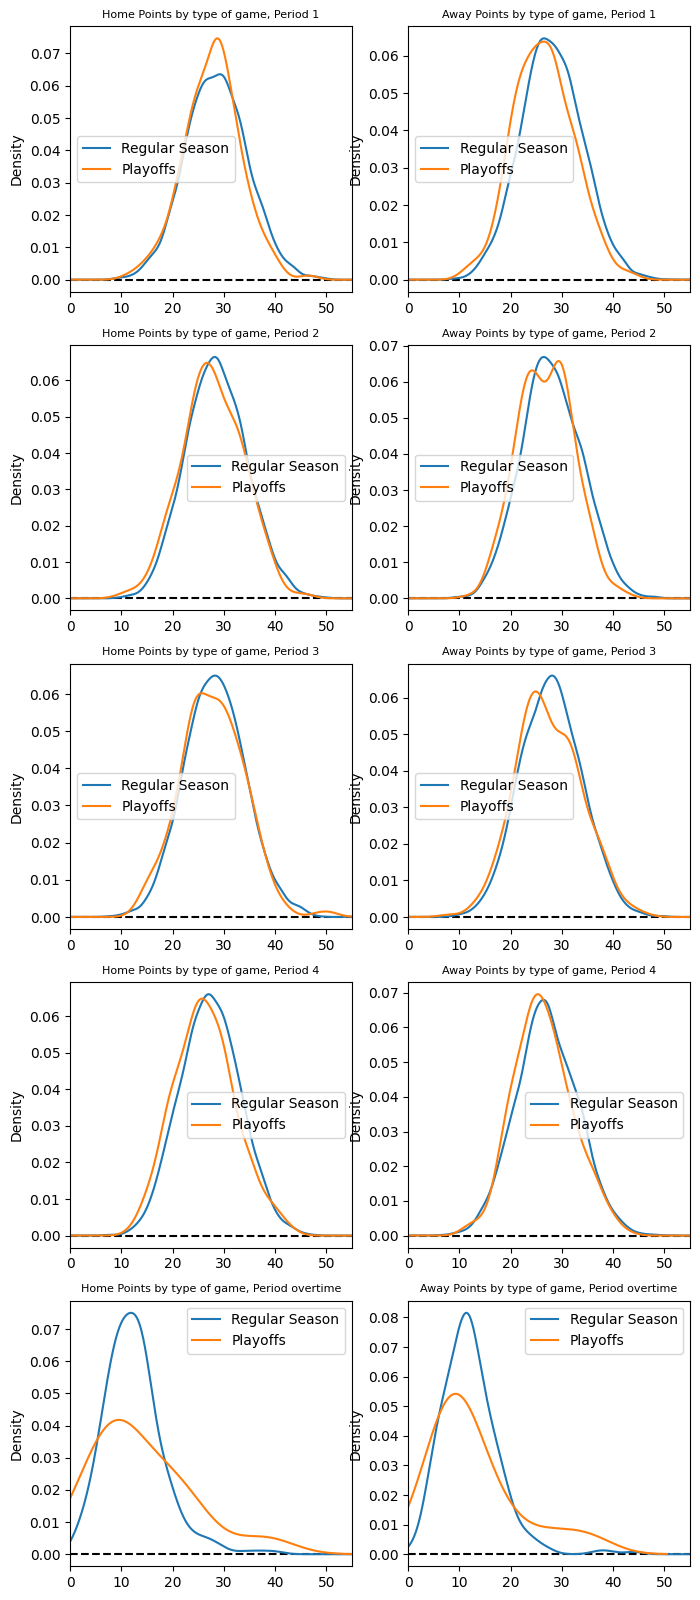

In [5]:
fig, axes = plt.subplots(5, 2, figsize = (8, 20))

for i, ax in enumerate(axes.flatten()):
    period  = (i//2) + 1
    query_statement = "period == " + str(period) if period <= 4 else "period >= " + str(period)
    period_legend = str(period) if period <= 4 else 'overtime'

    df_ = pbp['train']\
    .query(query_statement)\
    .groupby(['game_id', 'playoff_game'], as_index = False)\
    .agg({'hpts': ['min', 'max'], 'vpts': ['min', 'max']})\
    .assign(home_points = lambda x: x[('hpts', 'max')] - x[('hpts', 'min')])\
    .assign(away_points = lambda x: x[('vpts', 'max')] - x[('vpts', 'min')])\
    .groupby("playoff_game")
    
    if i % 2 == 0:
        df_["home_points"]\
        .plot(kind = "density", ax = ax, legend = True, xlim = [0, 55])
        ax.set_title('Home Points by type of game, Period ' + period_legend, fontsize =  8)
    else: 
        df_["away_points"]\
        .plot(kind = "density", ax = ax, legend = True, xlim = [0, 55])
        ax.set_title('Away Points by type of game, Period ' + period_legend, fontsize =  8)
    ax.legend(["Regular Season", "Playoffs"])
    ax.axhline(0, linestyle = '--', color = 'black', zorder = -3)
    
plt.show()

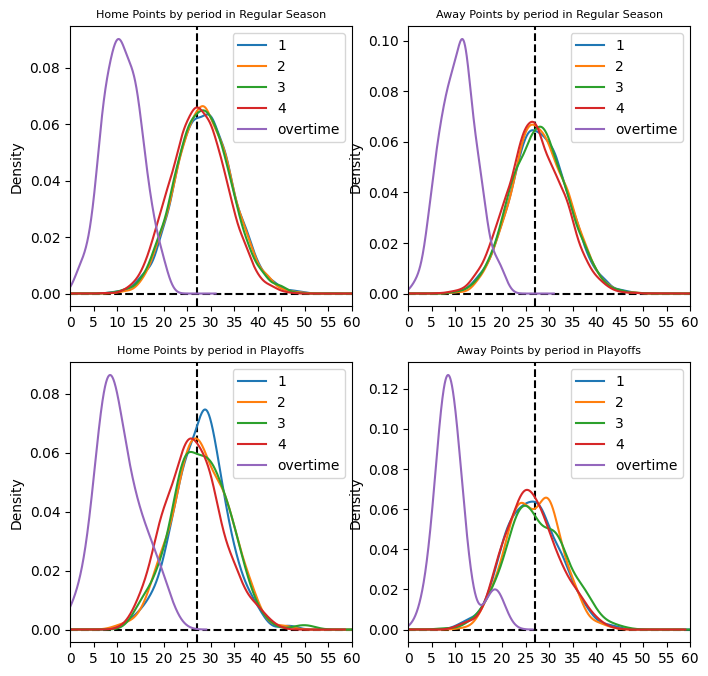

In [9]:
fig, axes = plt.subplots(2, 2, figsize = (8, 8))

for i, ax in enumerate(axes.flatten()):

    if i//2 == 0:
        df_ = pbp['train'].query("playoff_game == 0")
    else: 
        df_ = pbp['train'].query("playoff_game == 1")

    df_ = df_\
    .groupby(['game_id', 'period'], as_index = False)\
    .agg({'hpts': ['min', 'max'], 'vpts': ['min', 'max']})\
    .assign(home_points = lambda x: x[('hpts', 'max')] - x[('hpts', 'min')])\
    .assign(away_points = lambda x: x[('vpts', 'max')] - x[('vpts', 'min')])\
    .assign(period = lambda x: ['overtime' if min(5, i) == 5 else i for i in x['period']])\
    [['period', 'home_points', 'away_points']]\
    .groupby("period")

    if i % 2 == 0:
        df_["home_points"]\
        .plot(kind = "density", ax = ax, legend = True, xlim = [0, 55])
        if i // 2 == 0:
            ax.set_title('Home Points by period in Regular Season', fontsize =  8)
        else:
            ax.set_title('Home Points by period in Playoffs', fontsize =  8)
    else: 
        df_["away_points"]\
        .plot(kind = "density", ax = ax, legend = True, xlim = [0, 55])
        if i // 2 == 0:
            ax.set_title('Away Points by period in Regular Season', fontsize =  8)
        else:
            ax.set_title('Away Points by period in Playoffs', fontsize =  8)
        
    ax.set_xticks([i for i in range(0, 61, 5)]) 
    ax.axhline(0, linestyle = '--', color = 'black', zorder = -3)
    ax.axvline(27, linestyle = '--', color = 'black', zorder = -3)
plt.show()

In [10]:
pbp['train']\
.merge(pbp['train'].query("period >= 5")[['game_id']].drop_duplicates(), 
       how = 'inner')\
.query("period == 4 & time <= 300")\
.drop(columns = ['ind_last_minute','ind_last_20_seconds', 'ind_last_10_seconds', 
                 'period1','period2', 'period3','period4','period_overtime',
                 'lead', 'ball_possession'])\
.groupby("game_id")\
.apply(lambda df: df.iloc[0], include_groups = False)\
.assign(difpts = lambda x: x['hpts'] - x['vpts'])\
['difpts'].value_counts().reset_index().sort_values('difpts')\
.assign(perc = lambda x: 100 * x['count']/x['count'].sum())\
.assign(acm = lambda x: x['perc'].cumsum())\
.assign(cntacm = lambda x: x['count'].cumsum())\
.set_index('difpts')

,count,perc,acm,cntacm
difpts,,,,
-19,1,0.324675,0.324675,1
-16,2,0.649351,0.974026,3
-15,1,0.324675,1.298701,4
-14,4,1.298701,2.597403,8
-13,4,1.298701,3.896104,12
-12,3,0.974026,4.870130,15
-11,5,1.623377,6.493506,20
-10,8,2.597403,9.090909,28
-9,10,3.246753,12.337662,38


In [11]:
pbp['train']\
.merge(pbp['train'].query("period >= 5")[['game_id']].drop_duplicates().assign(ot = 1), 
       how = 'left')\
.assign(ot = lambda x: x['ot'].fillna(0))\
.query("period == 4 & time <= 300")\
.drop(columns = ['ind_last_minute','ind_last_20_seconds', 'ind_last_10_seconds',
                 'period1', 'period2', 'period3','period4','period_overtime', 
                 'lead','ball_possession'])\
.groupby("game_id")\
.apply(lambda df: df.iloc[0], include_groups = False)\
.assign(difpts = lambda x: x['hpts'] - x['vpts'])\
.query("difpts >= -3 and difpts <= 3")\
.reset_index()\
.merge(
    pbp['train'].query('period == 4').groupby("game_id", as_index = False)\
    [['hpts', 'vpts']].max().assign(final_dif = lambda x: x['hpts'] - x['vpts'])\
    [['game_id', 'final_dif']],
    how = 'left')\
['final_dif'].value_counts().reset_index()\
.sort_values('final_dif')\
.assign(perc = lambda x: 100 * x['count']/x['count'].sum())\
.assign(acm = lambda x: x['perc'].cumsum())\
.assign(cntacm = lambda x: x['count'].cumsum())


,final_dif,count,perc,acm,cntacm
43,-23,1,0.083822,0.083822,1
45,-21,1,0.083822,0.167645,2
39,-19,2,0.167645,0.335289,4
38,-18,2,0.167645,0.502934,6
40,-17,2,0.167645,0.670578,8
33,-16,4,0.335289,1.005868,12
32,-15,4,0.335289,1.341157,16
26,-14,13,1.089690,2.430847,29
29,-13,10,0.838223,3.269070,39
23,-12,17,1.424979,4.694049,56


In [12]:
df_boxscore.corr().stack().reset_index()\
.rename(columns = {0: 'cor'})\
.query("level_0 < level_1")\
.sort_values("cor", ascending = False)\
.iloc[:60]

,level_0,level_1,cor
572,home_FTA,home_FTM,0.920992
613,away_FTA,away_FTM,0.917080
1519,away_PMP,away_outcome,0.911575
1478,home_PMP,home_outcome,0.907434
367,away_3FGA,away_3FGM,0.903533
326,home_3FGA,home_3FGM,0.902428
75,away_FGM,away_points,0.853051
34,home_FGM,home_points,0.849547
863,away_RebDef,away_RebTot,0.824798
822,home_RebDef,home_RebTot,0.823627


In [14]:
df_prop_win_nba = df_games_nba\
.assign(outcome = lambda x: ['home' if h > a else 'away' for h, a in zip(x['HOME_PTS'], x['AWAY_PTS'])])\
.assign(season = lambda x: [str(i)[1:] for i in x['SEASON_ID']])\
.groupby(["season", 'outcome'], as_index = False, dropna = False).size()\
.pivot_table(index = 'season', columns = 'outcome', values = 'size')\
.assign(total = lambda x: x['away'] + x['home'])\
.assign(phome = lambda x: x['home']/x['total'])\
.assign(paway = lambda x: x['away']/x['total'])

df_prop_win_nba

outcome,away,home,total,phome,paway
season,,,,,
2008,510.0,805.0,1315.0,0.612167,0.387833
2009,526.0,786.0,1312.0,0.599085,0.400915
2010,514.0,797.0,1311.0,0.607933,0.392067
2011,437.0,637.0,1074.0,0.593110,0.406890
2012,508.0,806.0,1314.0,0.613394,0.386606
2013,555.0,764.0,1319.0,0.579227,0.420773
2014,556.0,755.0,1311.0,0.575896,0.424104
2015,534.0,782.0,1316.0,0.594225,0.405775
2016,546.0,763.0,1309.0,0.582888,0.417112


<Axes: xlabel='season'>

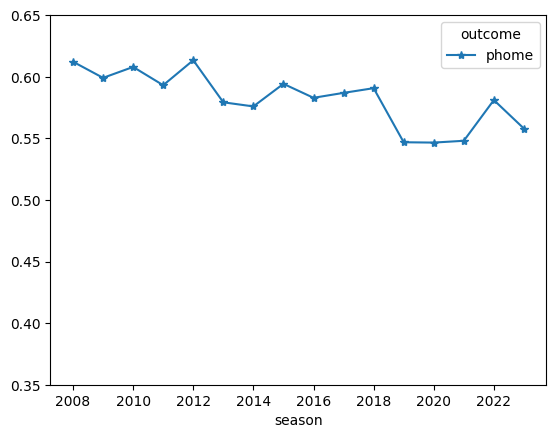

In [15]:
df_prop_win_nba[['phome']].plot(ylim = (0.35, 0.65), marker = "*")

In [16]:
with open(data_folder + 'df_categorical.pkl', 'rb') as f:
    df_categorical_outcome = pickle.load(f).rename(columns = {'game_id': 'GAME_ID'})

In [17]:
df_prop_games_nba = df_games_nba\
.merge(df_categorical_outcome, how = 'left')\
.query("split.notna()")

In [18]:
df_prop_games_nba_home = df_prop_games_nba\
.assign(home_outcome = lambda df: df['home_outcome'] / 20)\
.assign(win_team = lambda df: ['h' if h > a else 'a' for h, a in zip(df['HOME_PTS'], df['AWAY_PTS'])])\
.groupby(["home_outcome", "win_team"], as_index = False, dropna = False).size()\
.pivot_table(index = 'home_outcome', columns = 'win_team', values = 'size', fill_value = 0)\
.assign(soma = lambda df: df['a'] + df['h'])\
.assign(perch = lambda df: 100 * df['h'] / df['soma'])

df_prop_games_nba_home

win_team,a,h,soma,perch
home_outcome,,,,
0.00,3.0,2.0,5.0,40.000000
0.05,16.0,2.0,18.0,11.111111
0.10,37.0,19.0,56.0,33.928571
0.15,101.0,48.0,149.0,32.214765
0.20,150.0,73.0,223.0,32.735426
0.25,194.0,117.0,311.0,37.620579
0.30,260.0,154.0,414.0,37.198068
0.35,259.0,221.0,480.0,46.041667
0.40,306.0,324.0,630.0,51.428571


In [19]:
df_prop_games_nba_away = df_prop_games_nba\
.assign(away_outcome = lambda df: df['away_outcome'] / 20)\
.assign(win_team = lambda df: ['h' if h > a else 'a' for h, a in zip(df['HOME_PTS'], df['AWAY_PTS'])])\
.groupby(["away_outcome", "win_team"], as_index = False, dropna = False).size()\
.pivot_table(index = 'away_outcome', columns = 'win_team', values = 'size', fill_value = 0)\
.assign(soma = lambda df: df['a'] + df['h'])\
.assign(perca = lambda df: 100 * df['a'] / df['soma'])

df_prop_games_nba_away

win_team,a,h,soma,perca
away_outcome,,,,
0.00,0.0,5.0,5.0,0.000000
0.05,6.0,16.0,22.0,27.272727
0.10,14.0,38.0,52.0,26.923077
0.15,34.0,101.0,135.0,25.185185
0.20,68.0,171.0,239.0,28.451883
0.25,94.0,231.0,325.0,28.923077
0.30,112.0,279.0,391.0,28.644501
0.35,184.0,287.0,471.0,39.065817
0.40,242.0,342.0,584.0,41.438356


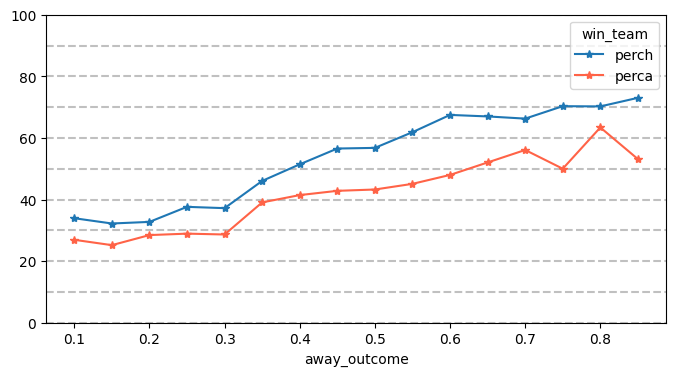

In [20]:
fig, ax = plt.subplots(1, 1, figsize = (8, 4))
df_prop_games_nba_home.query("soma >= 30")[['perch']].plot(marker = '*', ylim = (0, 100), ax = ax)
df_prop_games_nba_away.query("soma >= 30")[['perca']].plot(marker = '*', ax = ax, color = 'tomato')

for i in range(0, 101, 10): ax.axhline(i, color = 'silver', zorder = -3, linestyle = '--')
plt.show()

In [21]:
df_prop_games_nba_dif = df_prop_games_nba\
.assign(away_outcome = lambda df: df['away_outcome'] / 20)\
.assign(home_outcome = lambda df: df['home_outcome'] / 20)\
.assign(outcome = lambda df: df['home_outcome'] - df['away_outcome'])\
.assign(win_team = lambda df: ['h' if h > a else 'a' for h, a in zip(df['HOME_PTS'], df['AWAY_PTS'])])\
.assign(outcome = lambda df: [min(0.70, max(i, -0.700)) for i in df['outcome']])\
.groupby(["outcome", "win_team"], as_index = False, dropna = False).size()\
.pivot_table(index = 'outcome', columns = 'win_team', values = 'size', aggfunc = 'sum', fill_value = 0)\
.assign(soma = lambda df: df['a'] + df['h'])\
.assign(perca = lambda df: 100 * df['a'] / (df['h'] + df['a']))


In [22]:
df_prop_games_nba_dif.query("soma >= 30")

win_team,a,h,soma,perca
outcome,,,,
-0.50,34,13,47,72.340426
-0.45,33,13,46,71.739130
-0.45,39,12,51,76.470588
-0.40,63,33,96,65.625000
-0.40,45,23,68,66.176471
-0.35,48,18,66,72.727273
-0.35,73,49,122,59.836066
-0.30,85,36,121,70.247934
-0.30,53,28,81,65.432099


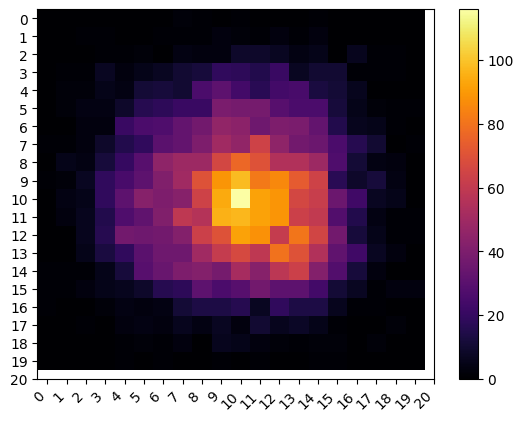

In [23]:
df_heatmap = df_boxscore[['home_outcome', 'away_outcome']]\
.merge(df_games_nba.set_index("GAME_ID")[['HOME_PTS', 'AWAY_PTS']], how = 'inner', left_index = True, right_index = True)\
.assign(outcome = lambda x: ['h' if h > a else 'a' for h, a in zip(x['HOME_PTS'], x['AWAY_PTS'])])\
.groupby(['home_outcome', 'away_outcome', 'outcome'], as_index = False).size()\
.pivot_table(index = ['home_outcome', 'away_outcome'], columns = 'outcome', values = 'size', fill_value = 0)\
.reset_index()\
.assign(total = lambda x: x['a'] + x['h'])\
.assign(proph = lambda x: x['h']/x['total'])\
.assign(proph = lambda x: [2 if i >= 10 and j > 0.65 else 1 if i >= 10 and j > 0.5 else -2 if i >= 10 and j <= 0.35 else -1 if i >= 10 and j <= 0.5 else 0  for i, j in zip(x['total'], x['proph'])])\
.assign(home_outcome = lambda x: 20 * x['home_outcome'])\
.assign(away_outcome = lambda x: 20 * x['away_outcome'])\
.pivot_table(index = ['home_outcome'], columns = ['away_outcome'], values = 'total', fill_value = 0)

heatmap2d(df_heatmap, cmap = 'inferno')
plt.show()

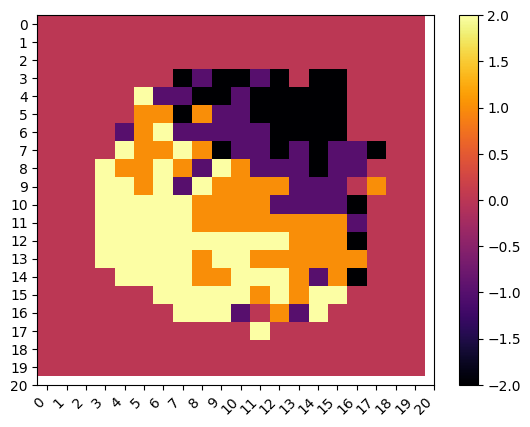

In [24]:
df_heatmap = df_boxscore[['home_outcome', 'away_outcome']]\
.merge(df_games_nba.set_index("GAME_ID")[['HOME_PTS', 'AWAY_PTS']], how = 'inner', left_index = True, right_index = True)\
.assign(outcome = lambda x: ['h' if h > a else 'a' for h, a in zip(x['HOME_PTS'], x['AWAY_PTS'])])\
.groupby(['home_outcome', 'away_outcome', 'outcome'], as_index = False).size()\
.pivot_table(index = ['home_outcome', 'away_outcome'], columns = 'outcome', values = 'size', fill_value = 0)\
.reset_index()\
.assign(total = lambda x: x['a'] + x['h'])\
.assign(proph = lambda x: x['h']/x['total'])\
.assign(proph = lambda x: [2 if i >= 10 and j > 0.65 else 1 if i >= 10 and j > 0.5 else -2 if i >= 10 and j <= 0.35 else -1 if i >= 10 and j <= 0.5 else 0  for i, j in zip(x['total'], x['proph'])])\
.assign(home_outcome = lambda x: 20 * x['home_outcome'])\
.assign(away_outcome = lambda x: 20 * x['away_outcome'])\
.pivot_table(index = ['home_outcome'], columns = ['away_outcome'], values = 'proph', fill_value = 0)

heatmap2d(df_heatmap, cmap = 'inferno')
plt.show()

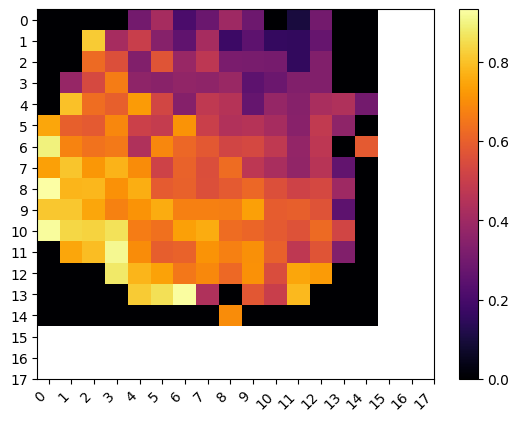

In [25]:
#df_heatmap = 
df_boxscore[['home_outcome', 'away_outcome']]\
.merge(df_games_nba.set_index("GAME_ID")[['HOME_PTS', 'AWAY_PTS']], how = 'inner', left_index = True, right_index = True)\
.assign(outcome = lambda x: ['h' if h > a else 'a' for h, a in zip(x['HOME_PTS'], x['AWAY_PTS'])])\
.groupby(['home_outcome', 'away_outcome', 'outcome'], as_index = False).size()\
.pivot_table(index = ['home_outcome', 'away_outcome'], columns = 'outcome', values = 'size', fill_value = 0)\
.reset_index()\
.assign(total = lambda x: x['a'] + x['h'])\
.assign(proph = lambda x: x['h']/x['total'])\
.query("total >= 10")\
.pivot_table(index = ['home_outcome'], columns = ['away_outcome'], values = 'proph', fill_value = 0)\
.pipe(func = heatmap2d, cmap = 'inferno', max_values = 18)
plt.show()